# Surface plasmon polaritons on metamaterials, learned from Maxwell's equations

**A fifteen-minute walkthrough.** Dr Robert Michael Jones · [repository](https://github.com/JonesRobM/Metamaterials_PINN) · [project site](https://jonesrobm.github.io/Metamaterials_PINN/)

This notebook is the middle layer between the README and the experiment scripts. It
tells the story of the project end to end, and it *computes* the physics as it goes
rather than describing it.

What runs here: closed-form electromagnetics, an exact transfer-matrix solve of a real
13-interface Ag/silica stack, and the effective-medium approximation that the project
sets out to beat. What does **not** run here: any network training. The trained-network
numbers are read from the `metrics.json` files that each experiment writes alongside its
figures, and two precomputed figures are embedded. The whole notebook executes in well
under a minute on a laptop CPU.

| section | question |
| --- | --- |
| 1 | Why not just mesh it, or homogenise it? |
| 2 | What is the physics, concretely, in numbers? |
| 3 | Why does the obvious PINN loss fail? |
| 4 | What makes a layered structure tractable for a smooth network? |
| 5 | How accurate is it, against what? |
| 6 | Where does all of this stop being true? |

## 1. The problem

A plasmonic metamaterial is a structure built from features far smaller than the
wavelength of the light it manipulates — here, silver and silica layers tens of
nanometres thick, illuminated at 633 nm. Two standard ways to solve for the fields:

1. **Mesh the structure.** Finite elements or FDTD on the actual geometry. Exact in
   principle, but the mesh has to resolve a 9 nm silver layer inside a domain hundreds
   of nanometres across, and the cost grows with the feature-to-wavelength ratio, which
   is precisely the ratio a metamaterial is designed to make extreme.
2. **Homogenise it.** Replace the stack by one uniform uniaxial medium with an effective
   permittivity tensor. Cheap, analytic, and the workhorse of the field — but it is the
   leading term of a long-wavelength expansion, and how wrong it is at a given period is
   rarely measured.

This project explores a third option: represent the field with a neural network and
train it against the residual of Maxwell's equations themselves, so the structure enters
through the coefficient ε(z) rather than through a mesh. The interesting question is not
whether that is possible — it is — but how accurate it is, measured against references
that are themselves independently validated. Every number below has such a reference
behind it.

In [1]:
from pathlib import Path

import json
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

from src.constants import C0
from src.effective_medium import (
    classify_anisotropy,
    drude_permittivity,
    hmm_permittivities,
    max_layer_period,
    photon_energy_ev,
)
from src.physics.metamaterial import MetamaterialProperties
from src import transfer_matrix as tm

%matplotlib inline
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 110,
    "font.size": 9,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.titlesize": 10,
    "legend.frameon": False,
})

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIGURES = ROOT / "figures"

# Colours used consistently throughout: truth / homogenised / network.
C_TMM, C_EMT, C_PINN = "black", "tab:blue", "tab:orange"
print("project root:", ROOT)

project root: /Users/robjones/Documents/Personal/Projects/Physics/Metamaterials_PINN


## 2. The physics, executably

### 2.1 The sign convention, and why it is stated first

Everything here uses the $e^{-i\omega t}$ time convention. That single choice fixes the
sign of every imaginary part in the project:

- lossy media have $\operatorname{Im}\varepsilon > 0$,
- decaying waves have $\operatorname{Im}k > 0$,
- transverse decay constants satisfy $\operatorname{Re}\kappa > 0$.

The governing equations in that convention are

$$\nabla\times\mathbf{E} = i\omega\mu_0\mathbf{H},\qquad
\nabla\times\mathbf{H} = -i\omega\varepsilon_0\bar\varepsilon\,\mathbf{E},\qquad
\nabla\cdot(\bar\varepsilon\mathbf{E}) = 0,\qquad
\nabla\cdot\mathbf{H} = 0 .$$

This is worth stating plainly because the codebase was once internally inconsistent: the
curl signs followed $e^{+i\omega t}$ while every material parameter assumed
$e^{-i\omega t}$. The fix was two sign flips rather than negating every permittivity in
the project, and the convention now appears in each module's docstring. A convention bug
of that kind does not produce an error — it produces a plausible answer with the loss on
the wrong side.

### 2.2 A real structure, not a hand-picked tensor

The metamaterial here is an **Ag/silica multilayer**: alternating silver and silica
layers of period $a$ with metal fill fraction $f = a_\mathrm{metal}/a$. Silver is a Drude
fit, $\varepsilon(\omega) = \varepsilon_\infty - \omega_p^2/(\omega^2 + i\gamma\omega)$
with $\varepsilon_\infty = 3.7$, $\hbar\omega_p = 9.1$ eV, $\hbar\gamma = 0.018$ eV.

Homogenising the stack in the long-wavelength limit gives a uniaxial tensor
$\bar\varepsilon = \mathrm{diag}(\varepsilon_t, \varepsilon_t, \varepsilon_n)$ whose two
components come from *different* continuity conditions at the layer boundaries.
Tangential $\mathbf{E}$ is continuous, so the in-plane field is the same in every layer
and the in-plane permittivity is an arithmetic mean. Normal $\mathbf{D}$ is continuous,
so the normal permittivity is a harmonic mean:

$$\varepsilon_t = f\varepsilon_m + (1-f)\varepsilon_d,\qquad
\varepsilon_n = \left[\frac{f}{\varepsilon_m} + \frac{1-f}{\varepsilon_d}\right]^{-1}.$$

Hold on to the second one — the fact that it is $D_z$, not $E_z$, that is continuous is
the whole of section 4.

In [2]:
LAMBDA0 = 633e-9                 # design wavelength (m)
OMEGA = 2.0 * np.pi * C0 / LAMBDA0
K0 = OMEGA / C0                  # free-space wavenumber (1/m)

FILL = 0.30                      # metal fill fraction f
EPS_SILICA = 2.25 + 0j           # silica layers
EPS_AIR = 1.0 + 0j               # superstrate

eps_ag = complex(drude_permittivity(OMEGA))
eps_t, eps_n = (complex(v) for v in hmm_permittivities(OMEGA, FILL, EPS_SILICA))

print(f"lambda0 = {LAMBDA0 * 1e9:.0f} nm   omega = {OMEGA:.6e} rad/s   k0 = {K0:.6e} 1/m")
print(f"eps_Ag (Drude)      = {eps_ag.real:+.6f} {eps_ag.imag:+.6f}j   (Im > 0: passive)")
print(f"eps_t  (in-plane)   = {eps_t.real:+.6f} {eps_t.imag:+.6f}j")
print(f"eps_n  (normal)     = {eps_n.real:+.6f} {eps_n.imag:+.6f}j")
print(f"anisotropy class    = {classify_anisotropy(eps_t, eps_n)}")

lambda0 = 633 nm   omega = 2.975753e+15 rad/s   k0 = 9.926043e+06 1/m
eps_Ag (Drude)      = -17.883449 +0.198349j   (Im > 0: passive)
eps_t  (in-plane)   = -3.790035 +0.059505j
eps_n  (normal)     = +3.397455 +0.002147j
anisotropy class    = type-II


`type-II` means $\operatorname{Re}\varepsilon_t < 0$ and $\operatorname{Re}\varepsilon_n > 0$:
the iso-frequency surface is a one-sheet hyperboloid, so the medium propagates waves with
arbitrarily large in-plane wavenumber. That is what makes these structures interesting,
and — see section 6 — it is also what eventually breaks the homogenisation, because
"period much smaller than the wavelength" is not a constraint the medium's own high-$k$
modes respect.

### 2.3 The surface mode

At a flat interface between the metamaterial ($z<0$) and a dielectric ($z>0$) the bound
TM surface mode has

$$k_\mathrm{spp}^2 = k_0^2\,
\frac{\varepsilon_d\,\varepsilon_n\,(\varepsilon_t - \varepsilon_d)}
     {\varepsilon_t\varepsilon_n - \varepsilon_d^2},\qquad
\kappa_d^2 = k_\mathrm{spp}^2 - \varepsilon_d k_0^2,\qquad
\kappa_m^2 = \varepsilon_t\!\left(\frac{k_\mathrm{spp}^2}{\varepsilon_n} - k_0^2\right).$$

Two details that matter in practice. First, the square-root branches are chosen
explicitly rather than left to the principal branch, which picks the wrong sheet near
resonances. Second, with loss present the matching condition
$\kappa_d/\varepsilon_d + \kappa_m/\varepsilon_t = 0$ also admits *radiative* quasi-roots
whose decay constants acquire small positive real parts, so identifying a genuinely bound
mode needs the extra non-radiative gate
$\operatorname{Re}k_\mathrm{spp} > \sqrt{\varepsilon_d}\,k_0$. `is_spp_supported()`
applies both tests.

In [3]:
hmm = MetamaterialProperties(eps_n, eps_t, optical_axis="z", omega=OMEGA)

k_emt = hmm.spp_wavevector(eps_dielectric=1.0)
_, kappa_d, kappa_m = hmm.decay_constants(eps_dielectric=1.0)

print(f"bound mode supported : {hmm.is_spp_supported(eps_dielectric=1.0)}")
print(f"k_spp (homogenised)  : {k_emt.real:.6e} {k_emt.imag:+.6e}j  1/m")
print(f"n_eff = Re k/k0      : {k_emt.real / K0:.6f}")
print(f"propagation length L : {hmm.propagation_length(eps_dielectric=1.0) * 1e6:.2f} um")
print(f"penetration, air     : {hmm.penetration_depth_dielectric(eps_dielectric=1.0) * 1e9:.1f} nm")
print(f"penetration, medium  : {hmm.penetration_depth_metamaterial(eps_dielectric=1.0) * 1e9:.1f} nm")

bound mode supported : True
k_spp (homogenised)  : 1.074920e+07 +1.177800e+04j  1/m
n_eff = Re k/k0      : 1.082929
propagation length L : 42.45 um
penetration, air     : 242.4 nm
penetration, medium  : 63.9 nm


Before trusting any of that, the analytics are pinned to a literature value. Feeding the
same routines the Johnson & Christy measurement for silver at 633 nm,
$\varepsilon = -18.3 + 0.55i$, should reproduce the textbook silver/air surface plasmon.

In [4]:
EPS_AG_JC = -18.3 + 0.55j            # Johnson & Christy, 633 nm
silver_jc = MetamaterialProperties(EPS_AG_JC, EPS_AG_JC, optical_axis="z", omega=OMEGA)

print("silver/air SPP at 633 nm from the Johnson & Christy permittivity")
print(f"  n_eff                    = {silver_jc.spp_wavevector().real / K0:.4f}")
print(f"  propagation length L     = {silver_jc.propagation_length() * 1e6:.1f} um")
print(f"  penetration into metal   = {silver_jc.penetration_depth_metamaterial() * 1e9:.1f} nm")
print(f"  penetration into air     = {silver_jc.penetration_depth_dielectric() * 1e9:.0f} nm")
print()
print("The validation table quotes L = 56.4 um and delta_metal = 22.9 nm, both inside the")
print("literature bands for silver at this wavelength. That is the anchor for everything else.")

silver/air SPP at 633 nm from the Johnson & Christy permittivity
  n_eff                    = 1.0285
  propagation length L     = 56.4 um
  penetration into metal   = 22.9 nm
  penetration into air     = 419 nm

The validation table quotes L = 56.4 um and delta_metal = 22.9 nm, both inside the
literature bands for silver at this wavelength. That is the anchor for everything else.


### 2.4 The dispersion curve and the bound-mode region

Sweeping the frequency does two things at once: the Drude silver disperses, and so
therefore does the homogenised tensor. The band actually used by the frequency-conditioned
experiments in this project is 450–885 nm, which is 65% of the centre frequency wide. The
blue edge is set by the Drude model, which has no interband transitions and degrades below
about 450 nm.

In [5]:
lam_scan = np.linspace(380e-9, 1300e-9, 1400)
w_scan = 2.0 * np.pi * C0 / lam_scan
hw_scan = photon_energy_ev(w_scan)                       # photon energy (eV)

eps_t_s, eps_n_s = hmm_permittivities(w_scan, FILL, EPS_SILICA)

k_spp_s = np.full(w_scan.shape, np.nan + 0j)
bound_s = np.zeros(w_scan.shape, dtype=bool)
k_largest = np.zeros(w_scan.shape)          # largest wavenumber anywhere in the mode
for i, (w, et, en) in enumerate(zip(w_scan, eps_t_s, eps_n_s)):
    mat = MetamaterialProperties(complex(en), complex(et), optical_axis="z", omega=float(w))
    bound_s[i] = mat.is_spp_supported(eps_dielectric=1.0)
    if bound_s[i]:
        k, kd, km = mat.decay_constants(eps_dielectric=1.0)
        k_spp_s[i] = k
        k_largest[i] = max(abs(k), abs(kd), abs(km))

BAND = (450e-9, 885.4e-9)                                # the trained band
hw_band = photon_energy_ev(2.0 * np.pi * C0 / np.array(BAND))
in_band = (lam_scan >= BAND[0]) & (lam_scan <= BAND[1])

# The design rule the project uses: the period must be at least 10x smaller than the
# shortest wavelength the mode contains, anywhere in the band.
A_MAX = float(max_layer_period(k_largest[in_band].max()))

print(f"bound over {bound_s.mean() * 100:.0f}% of the scanned window "
      f"({lam_scan[0] * 1e9:.0f}-{lam_scan[-1] * 1e9:.0f} nm)")
print(f"trained band {BAND[1] * 1e9:.1f} nm -> {BAND[0] * 1e9:.0f} nm "
      f"= {hw_band[1]:.3f} - {hw_band[0]:.3f} eV")
print(f"largest wavenumber in the mode over that band : {k_largest[in_band].max():.4e} 1/m")
print(f"-> max_layer_period (the a << lambda rule)     : {A_MAX * 1e9:.1f} nm")

bound over 97% of the scanned window (380-1300 nm)
trained band 885.4 nm -> 450 nm = 1.400 - 2.755 eV
largest wavenumber in the mode over that band : 1.8958e+07 1/m
-> max_layer_period (the a << lambda rule)     : 33.1 nm


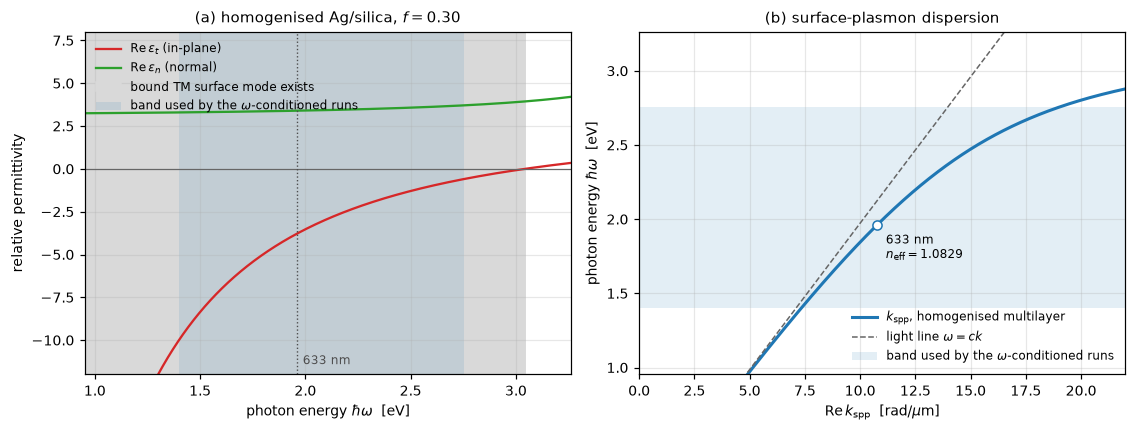

In [6]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10.4, 4.0))

# --- (a) the two effective permittivities, and where a bound mode exists -----
ax0.plot(hw_scan, np.real(eps_t_s), color="tab:red", label=r"$\mathrm{Re}\,\varepsilon_t$ (in-plane)")
ax0.plot(hw_scan, np.real(eps_n_s), color="tab:green", label=r"$\mathrm{Re}\,\varepsilon_n$ (normal)")
ax0.axhline(0.0, color="0.4", lw=0.8)
ax0.fill_between(hw_scan, -12, 8, where=bound_s, color="0.85", zorder=0,
                 label="bound TM surface mode exists")
ax0.axvspan(hw_band[1], hw_band[0], color="tab:blue", alpha=0.12, zorder=1, lw=0,
            label="band used by the $\\omega$-conditioned runs")
ax0.axvline(photon_energy_ev(OMEGA), color="0.3", lw=0.9, ls=":")
ax0.annotate("633 nm", xy=(photon_energy_ev(OMEGA), -11.4), xytext=(4, 0),
             textcoords="offset points", fontsize=8, color="0.3")
ax0.set_xlim(hw_scan.min(), hw_scan.max())
ax0.set_ylim(-12, 8)
ax0.set_xlabel(r"photon energy $\hbar\omega$  [eV]")
ax0.set_ylabel(r"relative permittivity")
ax0.set_title("(a) homogenised Ag/silica, $f = 0.30$")
ax0.legend(loc="upper left", fontsize=8)

# --- (b) the SPP dispersion curve -------------------------------------------
ok = np.isfinite(k_spp_s.real)
ax1.plot(k_spp_s.real[ok] * 1e-6, hw_scan[ok], color=C_EMT, lw=2,
         label=r"$k_\mathrm{spp}$, homogenised multilayer")
ax1.plot(hw_scan * K0 / photon_energy_ev(OMEGA) * 1e-6, hw_scan, color="0.4", ls="--", lw=1,
         label=r"light line $\omega = ck$")
ax1.axhspan(hw_band[1], hw_band[0], color="tab:blue", alpha=0.12, zorder=0, lw=0,
            label="band used by the $\\omega$-conditioned runs")
ax1.plot(k_emt.real * 1e-6, photon_energy_ev(OMEGA), "o", color=C_EMT, ms=6,
         mfc="white", zorder=5)
ax1.annotate(f"633 nm\n$n_{{\\rm eff}} = {k_emt.real / K0:.4f}$",
             xy=(k_emt.real * 1e-6, photon_energy_ev(OMEGA)),
             xytext=(6, -22), textcoords="offset points", fontsize=8)
ax1.set_xlim(0, 22)
ax1.set_ylim(hw_scan.min(), hw_scan.max())
ax1.set_xlabel(r"$\mathrm{Re}\,k_\mathrm{spp}$  [rad/$\mu$m]")
ax1.set_ylabel(r"photon energy $\hbar\omega$  [eV]")
ax1.set_title("(b) surface-plasmon dispersion")
ax1.legend(loc="lower right", fontsize=8)

fig.tight_layout()
plt.show()

Panel (a) shows the mechanism. $\operatorname{Re}\varepsilon_t$ (arithmetic mean) is
dragged negative by the silver across the whole visible; $\operatorname{Re}\varepsilon_n$
(harmonic mean) stays positive and close to the silica value until much higher energy.
The bound TM mode needs $\varepsilon_t < 0$ with $\varepsilon_n > \varepsilon_d$ — note
that the familiar isotropic threshold $\varepsilon_m < -\varepsilon_d$ does *not* survive
anisotropy, which is exactly the kind of thing worth checking with the code rather than
recalling.

Panel (b) is the dispersion curve. It sits to the right of the light line — that is what
"bound" means here, and it is why an SPP cannot be excited by a plane wave from the air
side without a coupler. The curve bends away from the light line as the energy rises, and
reproducing that *bend* rather than merely the slope is the actual test for a
frequency-conditioned network (section 5).

## 3. Why the naive PINN fails

The obvious loss for a physics-informed network is the residual of the governing
equations at a cloud of collocation points:

$$\mathcal{L} = w_1\|\nabla\times\mathbf{E} - i\omega\mu_0\mathbf{H}\|^2
 + w_2\|\nabla\times\mathbf{H} + i\omega\varepsilon_0\bar\varepsilon\mathbf{E}\|^2
 + w_3\|\nabla\cdot\mathbf{D}\|^2 .$$

**This loss is minimised exactly by $\mathbf{E} = \mathbf{H} = 0$.** Maxwell's equations
in a source-free domain are linear and homogeneous, so the residual operator $R$ satisfies
$R(\alpha F) = \alpha R(F)$ for any field $F$ and any scalar $\alpha$, and therefore
$\mathcal{L}(\alpha F) = \alpha^2 \mathcal{L}(F)$. Two consequences:

1. For *any* trial field, shrinking its amplitude reduces the loss quadratically, all the
   way to zero. There is always a descent direction pointing at the trivial field.
2. For the *exact* solution, the loss is zero along the entire ray $\alpha F^\star$,
   including $\alpha = 0$. The physics residual cannot distinguish the right answer from
   nothing at all.

This is not a hypothetical. Two experiments in this project converged confidently to the
trivial field before a boundary anchor was added — one of them left a checkpoint whose
field amplitude was $\sim 10^{-6}$ and whose training curve looked entirely healthy. That
is the most instructive thing in the repository, so it is stated in the README rather than
quietly overwritten.

The fix is a soft Dirichlet anchor on the domain boundary, taken from the reference
solution, plus a physics-loss ramp that weights the anchor heavily at first. Every
experiment here carries one. The cell below measures both terms along the amplitude ray,
using the exact transfer-matrix mode of the multilayer built in section 4 and, for
contrast, a plausible but wrong homogenised guess.

In [7]:
# --- the structure (built in full in section 4) ------------------------------
def multilayer_stack(period, n_periods, fill=FILL, eps_metal=None, eps_d=EPS_SILICA,
                     termination="metal", eps_super=EPS_AIR):
    '''(eps_layers, thicknesses) for src.transfer_matrix, ordered by increasing z.

    eps_layers[0] is the semi-infinite silver substrate and eps_layers[-1] the
    superstrate; the interior is n_periods bilayers. "metal" termination puts a full
    f*a silver layer against the superstrate, "half-metal" a f*a/2 one.
    '''
    metal = eps_ag if eps_metal is None else complex(eps_metal)
    d_m, d_d = fill * period, (1.0 - fill) * period
    top_down = []
    for index in range(int(n_periods)):
        if termination == "dielectric":
            top_down += [(eps_d, d_d), (metal, d_m)]
        elif termination == "half-metal" and index == 0:
            top_down += [(metal, 0.5 * d_m), (eps_d, d_d)]
        else:
            top_down += [(metal, d_m), (eps_d, d_d)]
    ordered = list(reversed(top_down))
    return ([metal] + [e for e, _ in ordered] + [complex(eps_super)],
            [d for _, d in ordered])


PERIOD, N_PERIODS = 30e-9, 6
eps_layers, thicknesses = multilayer_stack(PERIOD, N_PERIODS)
Z0 = -float(np.sum(thicknesses))                 # topmost interface at z = 0

k_tmm = tm.find_mode(k_emt, K0, eps_layers, thicknesses)   # exact mode of the real stack

# --- fields on the actual PINN domain ---------------------------------------
Z_LO, Z_HI = -210e-9, 348.943e-9                 # the experiment's z-extent
z = np.linspace(Z_LO, Z_HI, 6001)
prof = tm.mode_field_profile(k_tmm, K0, eps_layers, thicknesses, z, z0=Z0)

# Exclude a +-0.5 nm guard band around every interface: eps jumps there, so the
# derivative of a piecewise field is a delta function rather than a number. The
# training runs exclude exactly the same band.
interior = np.min(np.abs(z[:, None] - prof.boundaries[None, :]), axis=1) > 0.5e-9

def helmholtz_loss(H, k_x, kz_sq):
    # Mean squared residual of H'' + (eps k0^2 - k_x^2) H = 0, normalised.
    residual = (-kz_sq + prof.eps * K0**2 - k_x**2) * H
    return float(np.mean(np.abs(residual[interior])**2)
                 / (K0**4 * np.mean(np.abs(H[interior])**2)))

# (i) the exact mode: H'' = -k_z(z)^2 H inside every layer, by construction
kz_exact_sq = prof.k_z[prof.layer_index]**2
L_exact = helmholtz_loss(prof.H_y, k_tmm, kz_exact_sq)

# (ii) a wrong but plausible field: the homogenised half-space mode, exp(-kappa|z|),
#      scored against the *layered* eps(z) it does not actually solve
H_guess = np.where(z >= 0.0, np.exp(-kappa_d * z), np.exp(kappa_m * z))
kz_guess_sq = np.where(z >= 0.0, -kappa_d**2, -kappa_m**2)
L_guess = helmholtz_loss(H_guess, k_emt, kz_guess_sq)

print(f"Maxwell residual loss, exact transfer-matrix mode : {L_exact:.3e}")
print(f"Maxwell residual loss, homogenised guess          : {L_guess:.3e}")
for alpha in (1.0, 1e-1, 1e-3, 0.0):
    print(f"  alpha = {alpha:<6g}  exact ray {alpha**2 * L_exact:.3e}"
          f"   guess ray {alpha**2 * L_guess:.3e}")

Maxwell residual loss, exact transfer-matrix mode : 5.011e-31
Maxwell residual loss, homogenised guess          : 2.345e+01
  alpha = 1       exact ray 5.011e-31   guess ray 2.345e+01
  alpha = 0.1     exact ray 5.011e-33   guess ray 2.345e-01
  alpha = 0.001   exact ray 5.011e-37   guess ray 2.345e-05
  alpha = 0       exact ray 0.000e+00   guess ray 0.000e+00


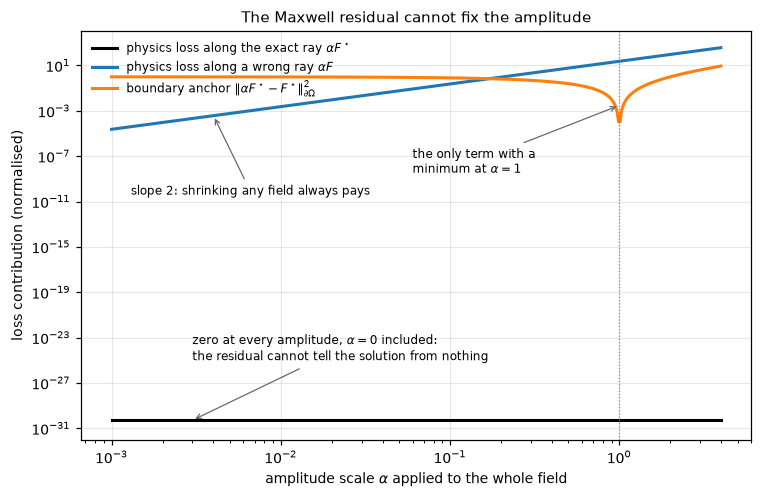

In [8]:
alpha = np.logspace(-3.0, 0.6, 400)

# Soft Dirichlet anchor on the two z-faces of the domain, target = the exact mode.
faces = np.array([prof.H_y[0], prof.H_y[-1]])
def anchor_loss(H_ray):
    values = np.array([H_ray[0], H_ray[-1]])
    return (np.sum(np.abs(alpha[:, None] * values[None, :] - faces[None, :])**2, axis=1)
            / np.sum(np.abs(faces)**2))

L_anchor = anchor_loss(prof.H_y)

fig, ax = plt.subplots(figsize=(7.0, 4.6))
ax.loglog(alpha, np.full_like(alpha, L_exact), color=C_TMM, lw=2,
          label=r"physics loss along the exact ray $\alpha F^\star$")
ax.loglog(alpha, alpha**2 * L_guess, color=C_EMT, lw=2,
          label=r"physics loss along a wrong ray $\alpha F$")
ax.loglog(alpha, L_anchor, color=C_PINN, lw=2,
          label=r"boundary anchor $\|\alpha F^\star - F^\star\|^2_{\partial\Omega}$")
ax.axvline(1.0, color="0.5", lw=0.8, ls=":")
ax.annotate("zero at every amplitude, $\\alpha = 0$ included:\n"
            "the residual cannot tell the solution from nothing",
            xy=(3e-3, L_exact), xytext=(3e-3, 1e-25), fontsize=8,
            arrowprops=dict(arrowstyle="->", lw=0.8, color="0.4"))
ax.annotate("slope 2: shrinking any field always pays",
            xy=(4e-3, 4e-3**2 * L_guess), xytext=(1.3e-3, 4e-11), fontsize=8,
            arrowprops=dict(arrowstyle="->", lw=0.8, color="0.4"))
ax.annotate("the only term with a\nminimum at $\\alpha = 1$", xy=(1.0, 3e-3),
            xytext=(0.06, 3e-9), fontsize=8,
            arrowprops=dict(arrowstyle="->", lw=0.8, color="0.4"))
ax.set_xlabel(r"amplitude scale $\alpha$ applied to the whole field")
ax.set_ylabel("loss contribution (normalised)")
ax.set_title("The Maxwell residual cannot fix the amplitude")
ax.set_ylim(1e-32, 1e4)
ax.legend(loc="upper left", fontsize=8)
fig.tight_layout()
plt.show()

The black line is the sharpest statement of the problem: along the ray through the *exact*
solution the Maxwell residual is zero to machine precision at every amplitude, $\alpha=0$
included. The blue line is the general case — a wrong field's residual falls as $\alpha^2$,
so gradient descent is always paid to shrink. Only the orange anchor term has a minimum at
$\alpha = 1$.

Three further ingredients turned out to be necessary for the harder cases, each for a
scale reason rather than a physics one:

- **A dimensionless frame.** In SI units the $\mathbf{H}$-equation residual is smaller than
  the $\mathbf{E}$-equation residual by the square of the free-space impedance ($\sim10^5$),
  so an optimiser simply ignores it.
- **Per-medium loss weighting.** The metal-side Ampère residual is hundreds of times
  stiffer than the dielectric side and dominates without rebalancing; in the multilayer run
  the curl-H residual penalises a field error in silver about 320 times harder than the same
  error in air, which is $|\varepsilon_{Ag}|^2$.
- **Input scaling by $k_0(\omega)$.** For frequency-conditioned runs, scaling coordinates by
  the *free-space* wavenumber makes the scaled system nearly frequency-independent. Scaling
  by $k_\mathrm{spp}$ would work better still — and would build in the very dispersion the
  experiment sets out to measure.

## 4. The displacement adapter

A multilayer looks like the hard case for a neural network. The field is genuinely
discontinuous, and a smooth activation function cannot produce a jump — it can only
approximate one with a steep ramp, which costs capacity, smears the interface and gets
worse with every additional layer.

The way out is to notice **which** component is discontinuous. For a TM mode
$F(x,z) = F(z)e^{ik_xx}$, Ampère's law with $\partial_x \to ik_x$ and $\partial_y \to 0$ gives

$$(\nabla\times\mathbf{H})_z = ik_xH_y = -i\omega\varepsilon_0\varepsilon E_z
\;\;\Longrightarrow\;\;
E_z = -\frac{k_xH_y}{\omega\varepsilon_0\varepsilon(z)}
\;\;\Longrightarrow\;\;
D_z = \varepsilon_0\varepsilon E_z = -\frac{k_xH_y}{\omega}.$$

The $\varepsilon$ cancels. $H_y$ and $E_x$ are continuous at every interface — that is
exactly the content of the transfer matrix's interface matrix — so $D_z$ inherits $H_y$'s
continuity for free, and the *only* discontinuous quantity in the whole problem is $E_z$,
which is exactly $D_z/\varepsilon(z)$.

So the network is asked to emit $\hat D_z$, and an adapter divides it by the local
$\varepsilon(z)$. The jump is then **exact by construction** — arithmetic, not
approximation — and the network only ever has to represent smooth functions.

The part worth pausing on: this argument never counts the interfaces. Going from one
interface to thirteen changes nothing but the $\varepsilon(z)$ lookup table. That
generalisation was verified rather than assumed: the repository's tests check on this very
stack that $H_y$, $E_x$ and $D_z$ are continuous at all 13 interfaces to better than
$10^{-7}$ relative, and that $E_z$ jumps by exactly
$\varepsilon_\mathrm{below}/\varepsilon_\mathrm{above}$ at each of them.

### 4.1 The structure

Silver ($\varepsilon_{Ag} = -17.883 + 0.198i$ at 633 nm) and silica ($\varepsilon = 2.25$),
fill fraction $f = 0.30$, period $a = 30$ nm, $N = 6$ periods: 9 nm of silver and 21 nm of
silica per period, 180 nm of stack, **13 interfaces**. Air above, a semi-infinite silver
substrate below so the mode is bound on both sides. The stack is metal-terminated — a full
9 nm silver layer against the air — which is the natural stack and, as section 6 shows, the
one homogenisation handles worst.

30 nm is a deliberate choice. It is the largest period at which the layers are still
comfortably resolvable, it is where the homogenisation error is unambiguously large, and it
is exactly the period the project's own $a \ll \lambda$ rule of thumb would wave through.

In [9]:
print(f"period a          = {PERIOD * 1e9:.0f} nm  ({FILL * PERIOD * 1e9:.0f} nm Ag "
      f"+ {(1 - FILL) * PERIOD * 1e9:.0f} nm SiO2)")
print(f"periods N         = {N_PERIODS}   -> stack {N_PERIODS * PERIOD * 1e9:.0f} nm, "
      f"{len(eps_layers) - 1} interfaces")
print(f"media in the stack= {len(eps_layers)} (silver substrate, 12 interior layers, air)")
print(f"stack wavenumber  = 2*pi/a = {2 * np.pi / PERIOD / K0:.1f} k0")
print(f"EMT rule of thumb : max_layer_period = {A_MAX * 1e9:.1f} nm"
      f"  -> a = {PERIOD * 1e9:.0f} nm passes it (section 6 shows the rule is too loose)")
print()
print("exact mode of the real stack, from the transfer matrix:")
print(f"  k_spp (TMM)     = {k_tmm.real:.6e} {k_tmm.imag:+.6e}j  1/m")
print(f"  n_eff (TMM)     = {k_tmm.real / K0:.6f}")
print(f"  k_spp (EMT)     = {k_emt.real:.6e} {k_emt.imag:+.6e}j  1/m")
print(f"  n_eff (EMT)     = {k_emt.real / K0:.6f}")
print(f"  residual leakage= {prof.leakage:.2e}   (0 at a true mode)")

period a          = 30 nm  (9 nm Ag + 21 nm SiO2)
periods N         = 6   -> stack 180 nm, 13 interfaces
media in the stack= 14 (silver substrate, 12 interior layers, air)
stack wavenumber  = 2*pi/a = 21.1 k0
EMT rule of thumb : max_layer_period = 33.1 nm  -> a = 30 nm passes it (section 6 shows the rule is too loose)

exact mode of the real stack, from the transfer matrix:
  k_spp (TMM)     = 1.050486e+07 +8.812634e+03j  1/m
  n_eff (TMM)     = 1.058313
  k_spp (EMT)     = 1.074920e+07 +1.177800e+04j  1/m
  n_eff (EMT)     = 1.082929
  residual leakage= 4.21e-16   (0 at a true mode)


### 4.2 The $\varepsilon(z)$ profile, and the sawtooth it produces

Three panels, all computed above from the transfer matrix: the piecewise-constant
$\varepsilon(z)$ the solver actually sees; the magnetic field, which is continuous but
*kinked* at every interface (its $z$-derivative jumps with $\varepsilon$, since
$\partial_zH_y = i\omega\varepsilon_0\varepsilon E_x$); and the pair $D_z$, $E_z$ — one
smooth, the other a sawtooth, differing only by division by $\varepsilon(z)$.

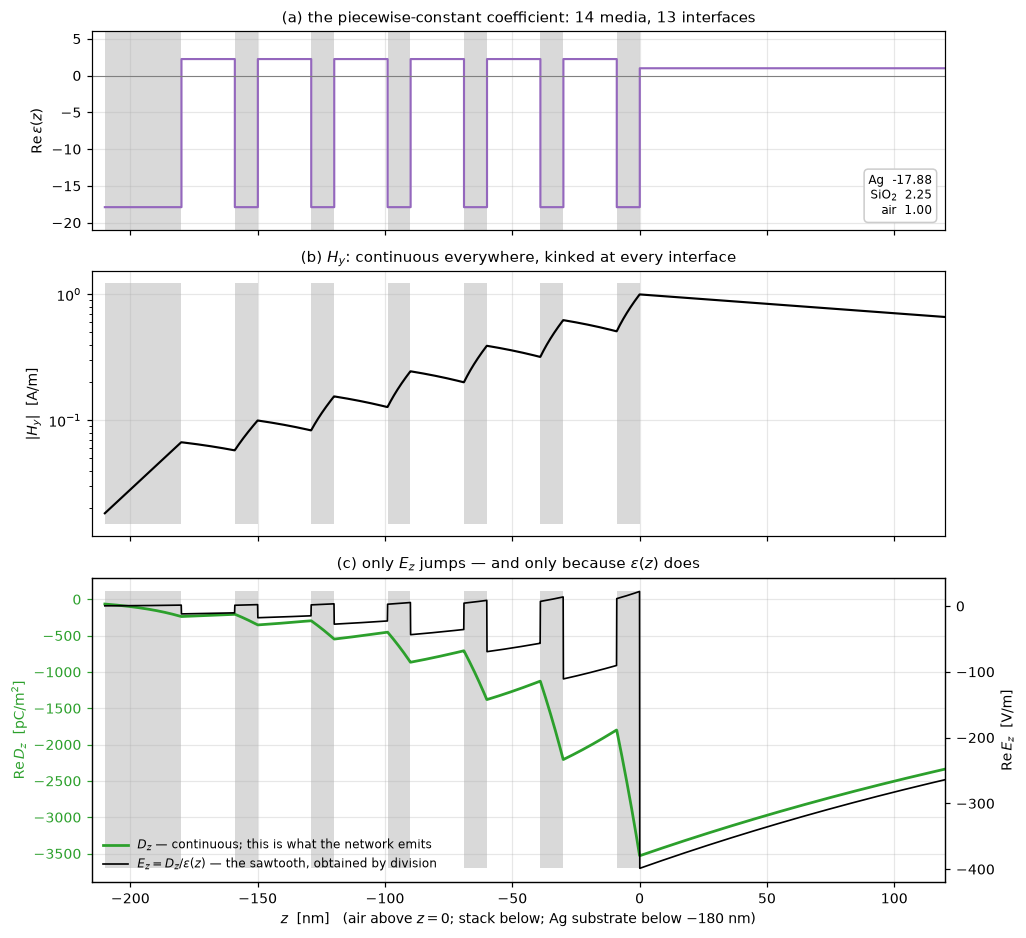

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(9.4, 8.6), sharex=True,
                         gridspec_kw={"height_ratios": [0.75, 1, 1.15]})
z_nm = z * 1e9
ag = np.isclose(np.real(prof.eps), eps_ag.real)     # silver layers, for shading
XLIM = (-215, 120)

# (a) the coefficient
axes[0].step(z_nm, np.real(prof.eps), where="post", color="tab:purple", lw=1.4)
axes[0].set_ylabel(r"$\mathrm{Re}\,\varepsilon(z)$")
axes[0].set_title("(a) the piecewise-constant coefficient: 14 media, 13 interfaces")
axes[0].set_ylim(-21, 6)
axes[0].axhline(0, color="0.5", lw=0.7)
axes[0].text(0.985, 0.06,
             f"Ag  {eps_ag.real:.2f}\nSiO$_2$  2.25\nair  1.00",
             transform=axes[0].transAxes, ha="right", va="bottom", fontsize=8,
             bbox=dict(fc="white", ec="0.8", boxstyle="round,pad=0.35"))

# (b) the magnetic field
axes[1].semilogy(z_nm, np.abs(prof.H_y), color=C_TMM, lw=1.4)
axes[1].set_ylabel(r"$|H_y|$  [A/m]")
axes[1].set_title(r"(b) $H_y$: continuous everywhere, kinked at every interface")

# (c) D_z (smooth, what the network emits) and E_z (the sawtooth), on twin axes
axc = axes[2]
axd = axc.twinx()
axd.grid(False)
line_d, = axc.plot(z_nm, np.real(prof.D_z) * 1e12, color="tab:green", lw=1.8)
line_e, = axd.plot(z_nm, np.real(prof.E_z), color=C_TMM, lw=1.1)
axc.set_ylabel(r"$\mathrm{Re}\,D_z$  [pC/m$^2$]", color="tab:green")
axd.set_ylabel(r"$\mathrm{Re}\,E_z$  [V/m]")
axc.tick_params(axis="y", colors="tab:green")
axc.set_xlabel(r"$z$  [nm]   (air above $z = 0$; stack below; Ag substrate below $-180$ nm)")
axc.set_title(r"(c) only $E_z$ jumps — and only because $\varepsilon(z)$ does")
axc.legend([line_d, line_e],
           [r"$D_z$ — continuous; this is what the network emits",
            r"$E_z = D_z/\varepsilon(z)$ — the sawtooth, obtained by division"],
           loc="lower left", fontsize=8)

for ax in axes:
    ax.fill_between(z_nm, *ax.get_ylim(), where=ag, color="0.85", zorder=0, lw=0)
    ax.set_xlim(*XLIM)
axd.set_xlim(*XLIM)
fig.tight_layout()
plt.show()

Panel (c) is the whole argument in one picture. The green curve is what the network has to
learn: smooth, monotone-ish, no structure at the interfaces at all. The black curve is what
comes out after dividing by $\varepsilon(z)$: a sawtooth with a jump of
$|\varepsilon_{Ag}|/\varepsilon_{SiO_2} \approx 7.9$ at every boundary, obtained for free.

Two checks, run against the profile just computed rather than asserted.

In [11]:
OFFSET = 1e-15                       # 1 fm either side of each interface
above = prof.boundaries + OFFSET
below = prof.boundaries - OFFSET
p_above = tm.mode_field_profile(k_tmm, K0, eps_layers, thicknesses, above, z0=Z0)
p_below = tm.mode_field_profile(k_tmm, K0, eps_layers, thicknesses, below, z0=Z0)

def rel_jump(a, b):
    return np.abs(a - b) / np.maximum(np.abs(a), np.abs(b))

print(f"interfaces checked                          : {len(prof.boundaries)}"
      f"   (sampled {OFFSET * 1e15:.0f} fm either side)")
print(f"max relative discontinuity in H_y           : {rel_jump(p_above.H_y, p_below.H_y).max():.2e}")
print(f"max relative discontinuity in E_x           : {rel_jump(p_above.E_x, p_below.E_x).max():.2e}")
print(f"max relative discontinuity in D_z           : {rel_jump(p_above.D_z, p_below.D_z).max():.2e}")

ratio = (p_below.E_z / p_above.E_z)                      # should equal eps_above / eps_below
expected = p_above.eps / p_below.eps
print(f"max error in the E_z jump ratio             : {np.abs(ratio - expected).max():.2e}")
print(f"smallest |jump ratio - 1| over 13 interfaces: {np.abs(np.abs(ratio) - 1).min():.2f}"
      "   (no interface is a near-identity: all 13 are real jumps)")

interfaces checked                          : 13   (sampled 1 fm either side)
max relative discontinuity in H_y           : 8.40e-08
max relative discontinuity in E_x           : 6.37e-08
max relative discontinuity in D_z           : 8.40e-08
max error in the E_z jump ratio             : 6.68e-07
smallest |jump ratio - 1| over 13 interfaces: 0.87   (no interface is a near-identity: all 13 are real jumps)


The residuals above are set by the 2 fm separation of the two sample points, not by the
physics: $H_y$, $E_x$ and $D_z$ are continuous to better than $10^{-7}$ relative at all
thirteen interfaces, and $E_z$ jumps by exactly the permittivity ratio at each to better
than $10^{-6}$ — which are the thresholds the repository's own test on this stack asserts.
The last line rules out the boring explanation: at the mildest of the thirteen interfaces
$|E_z|$ still changes by 87%, so none of them is a near-identity that a smooth network could
have got right by accident. A network that emits $\hat D_z$ and divides gets all of them
right by construction.

### 4.3 What the trained network does with it

Below is the figure the experiment produces. Black is the transfer-matrix truth, dashed
blue the homogenised model, orange the PINN trained on the real layers. Panel (b) is the
sawtooth; the homogenised model draws a smooth curve straight through it.

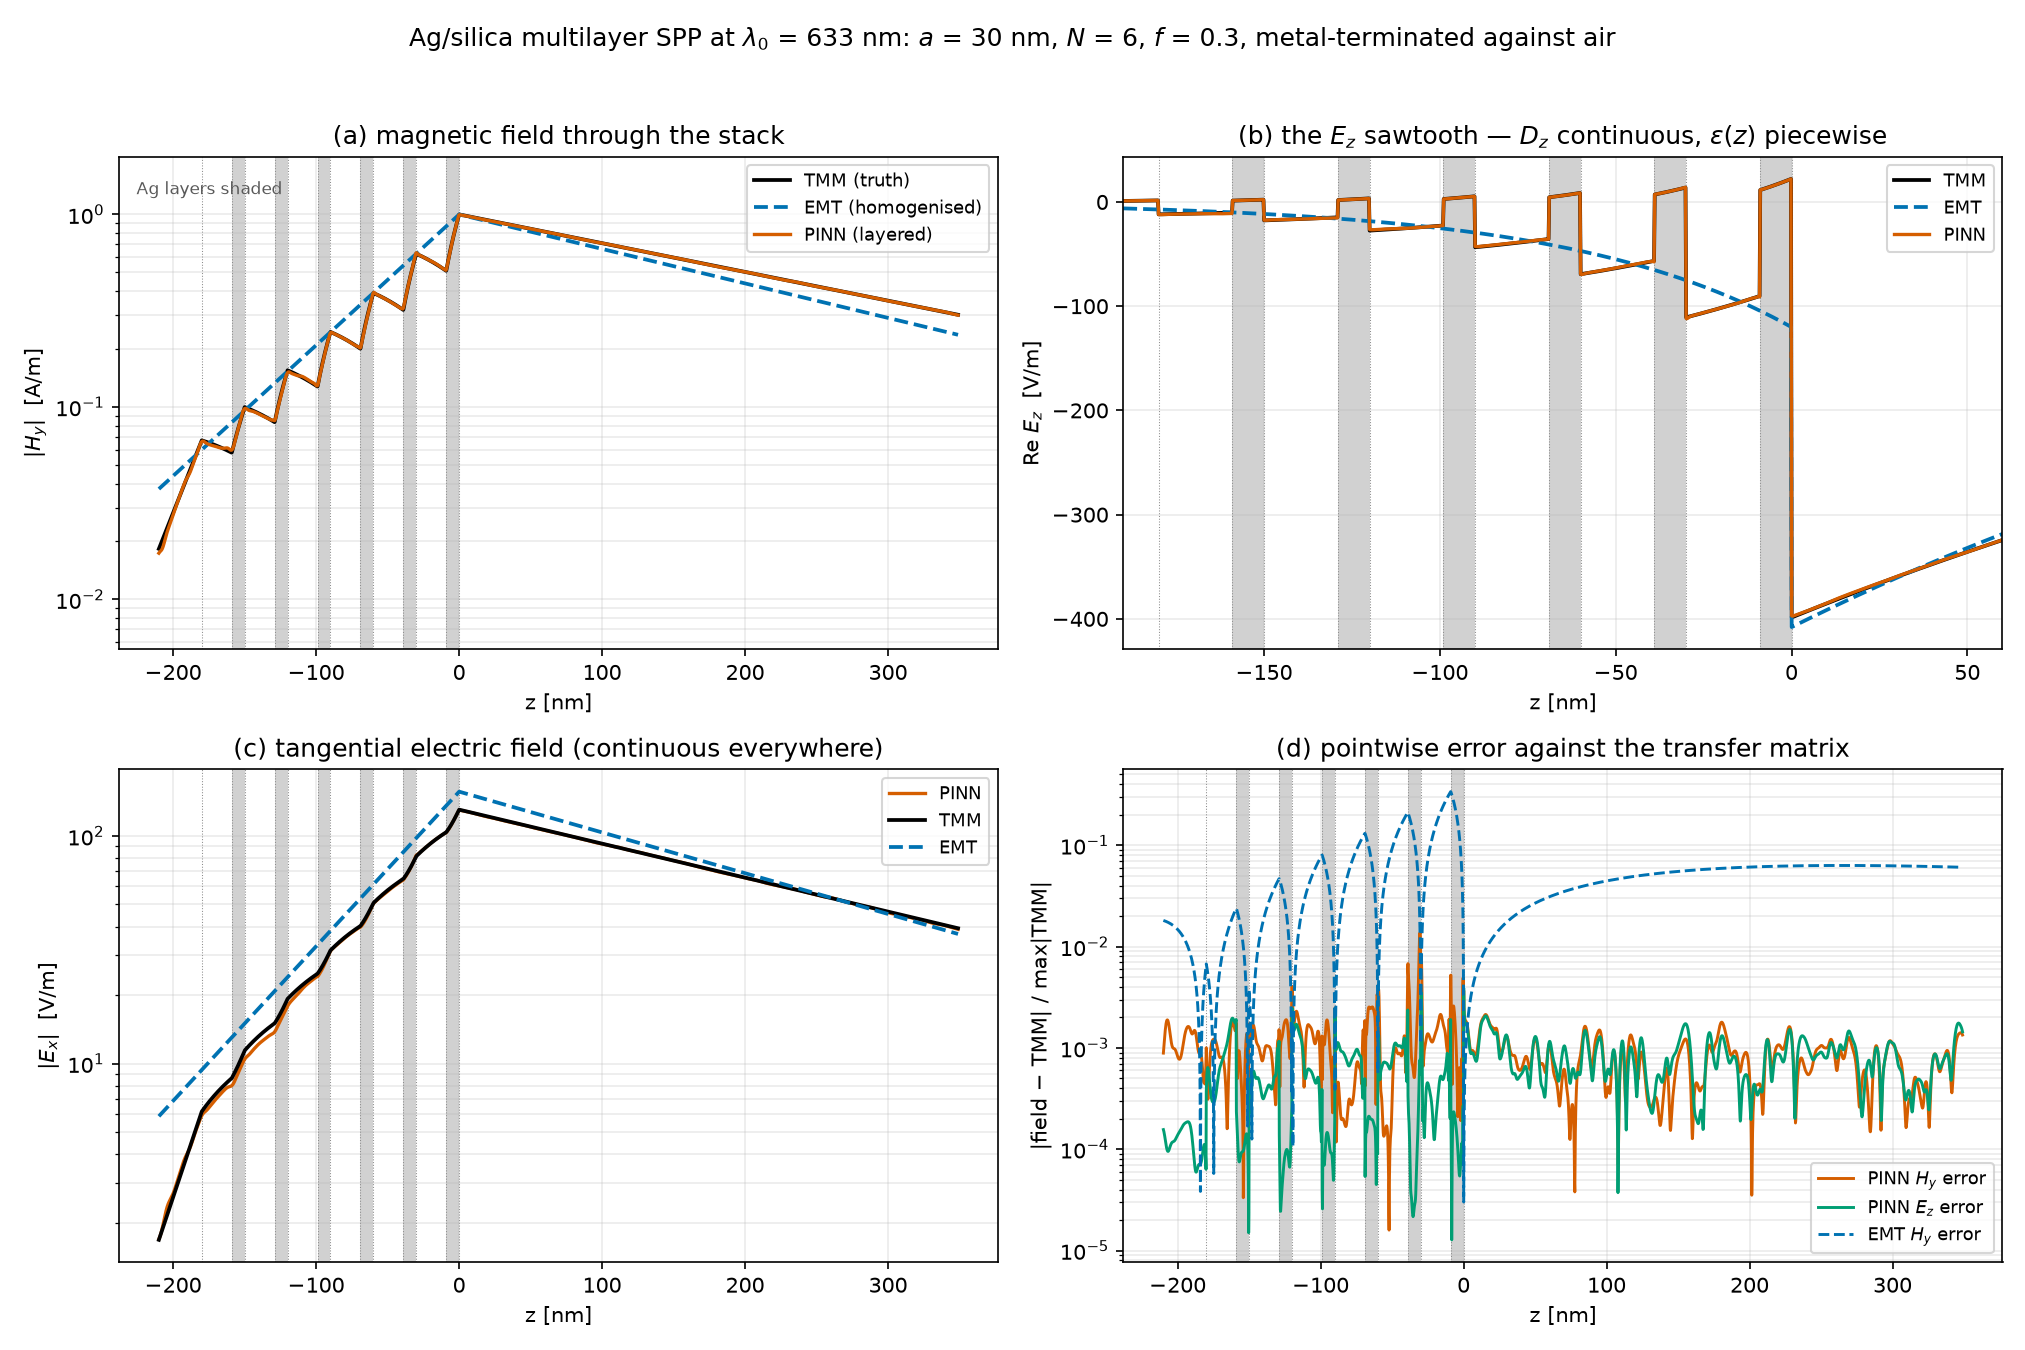

In [12]:
display(Image(filename=str(FIGURES / "multilayer" / "field_profiles.png"), width=980))

The outcome is the opposite of what a naive fit would give: **$E_z$ — the discontinuous
component — is the network's *most* accurate one.** Relative L2 by component: $E_z$
$3.17\times10^{-3}$ against $E_x$ $1.32\times10^{-2}$. The network never has to represent
the jump; it represents the smooth $\hat D_z$ and the sawtooth is arithmetic.

Panel (d) is worth reading too. The PINN's pointwise error sits around $10^{-3}$ everywhere,
flat across interfaces, while the homogenised model's error oscillates by two orders of
magnitude within each period — because it is not wrong *on average*, it is wrong in a way
that averages out.

## 5. Results

### 5.1 The validation ladder

Every experiment recovers a known solution from the physics loss plus a boundary anchor,
with **no interior data**. Errors are relative L2 against the reference field; dispersion
error is the relative error in $\operatorname{Re}k_\mathrm{spp}$, except for the plane wave
where the recovered wavelength is quoted.

| Experiment | Reference | Field error | Dispersion error |
| --- | --- | ---: | ---: |
| Plane wave in free space | analytic | 7.8×10⁻⁴ | 8.7×10⁻⁵ (wavelength) |
| SPP, silver/air at 633 nm | analytic | 3.9×10⁻³ | 8.3×10⁻⁵ |
| SPP, uniaxial metamaterial | analytic | 9.0×10⁻³ | 1.6×10⁻⁴ |
| Dispersion, one ω-conditioned network | analytic | 1.9×10⁻² worst | 2.6×10⁻³ worst |
| Design space, one (ω, *f*)-conditioned network | analytic | 3.5×10⁻² worst | 3.4×10⁻³ worst |
| **Real multilayer, 13 interfaces** | **transfer matrix** | **5.8×10⁻³** | **4.9×10⁻⁵** |

Underneath that sits a separate ladder for the physics routines themselves, each pinned to
an *independent* reference rather than to another part of the same codebase: the curl and
divergence operators against an exact extraordinary wave in a uniaxial crystal (residuals
$\sim10^{-15}$); the interface conditions against the exact Fresnel solution, TE and TM,
lossy included (machine precision; Brewster $|r_p| \sim 10^{-17}$); the transfer-matrix
solver against Fresnel, the closed-form SPP, and both branches of a thin metal film
($5\times10^{-17}$, $3.6\times10^{-19}$, correct long/short-range splitting). 865 tests.

Each PINN experiment also pushes its own *reference* solution through the identical
validation pipeline. If the analytical field scores a relative L2 of exactly zero and
recovers its wavevector to $10^{-10}$, then a reported network error of $10^{-3}$ is a
property of the network and not of the metric. That self-check caught a real issue: the
interface-continuity metric evaluated at $\pm2$ nm has a *physical* floor of roughly 8% for
a strongly confined silver mode, because the exact field genuinely differs across a 4 nm
gap. Without the self-check that floor would have been read as network error.

### 5.2 The three-way comparison

The transfer-matrix and effective-medium numbers below are computed live in this notebook;
the PINN numbers are read from the experiment's `metrics.json`.

In [13]:
metrics = json.loads((FIGURES / "multilayer" / "metrics.json").read_text())["metrics"]

k_pinn = complex(metrics["k_spp_re_pinn"], metrics["k_spp_im_pinn"])
rows = [
    ("Transfer matrix (truth)", k_tmm, None, None),
    ("Effective medium", k_emt, abs(k_emt.real - k_tmm.real) / k_tmm.real,
     abs(k_emt.imag - k_tmm.imag) / k_tmm.imag),
    ("PINN (layered)", k_pinn, metrics["k_spp_re_rel_error"], metrics["k_spp_im_rel_error"]),
]

header = f"{'':<26}{'Re k/k0':>12}{'error':>11}{'Im k [1/m]':>14}{'error':>10}"
print(header)
print("-" * len(header))
for name, k, e_re, e_im in rows:
    re_err = "  --  " if e_re is None else f"{e_re * 100:.4f}%"
    im_err = "  --  " if e_im is None else f"{e_im * 100:.2f}%"
    print(f"{name:<26}{k.real / K0:>12.6f}{re_err:>11}{k.imag:>14.1f}{im_err:>10}")
print()
print(f"error ratio, EMT / PINN:  Re {metrics['re_error_ratio_emt_over_pinn']:.0f}x"
      f"   Im {metrics['im_error_ratio_emt_over_pinn']:.1f}x")
print(f"field relative L2:        PINN {metrics['rel_l2_total']:.3e}"
      f"   EMT {metrics['rel_l2_total_emt_vs_tmm']:.3f}"
      f"   ({metrics['rel_l2_total_emt_vs_tmm'] / metrics['rel_l2_total']:.0f}x)")
print(f"E_z layer contrast:       PINN {metrics['ez_layer_contrast_pinn']:.3f}"
      f"   TMM {metrics['ez_layer_contrast_tmm']:.3f}"
      f"   ({metrics['ez_layer_contrast_rel_error'] * 100:.2f}% error)")

                               Re k/k0      error    Im k [1/m]     error
-------------------------------------------------------------------------
Transfer matrix (truth)       1.058313       --          8812.6      --  
Effective medium              1.082929    2.3260%       11778.0    33.65%
PINN (layered)                1.058365    0.0049%        8981.9     1.92%

error ratio, EMT / PINN:  Re 472x   Im 17.5x
field relative L2:        PINN 5.754e-03   EMT 0.247   (43x)
E_z layer contrast:       PINN 6.142   TMM 6.107   (0.57% error)


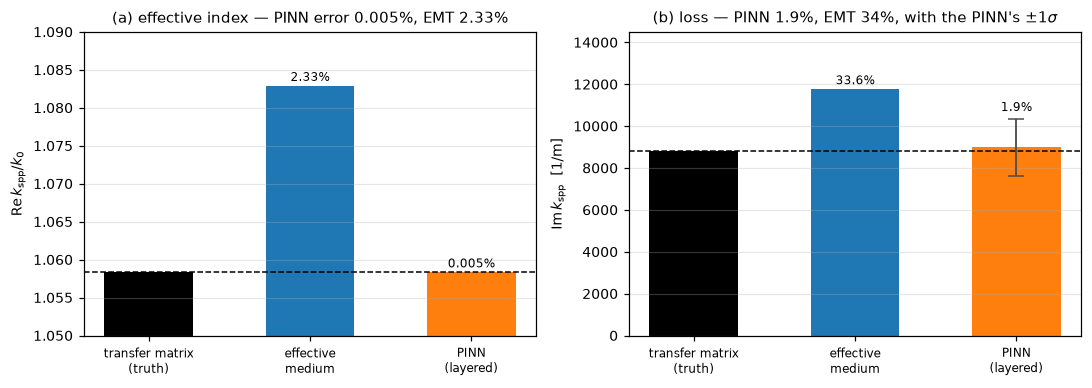

In [14]:
fig, (axr, axi) = plt.subplots(1, 2, figsize=(10.0, 3.6))
labels = ["transfer matrix\n(truth)", "effective\nmedium", "PINN\n(layered)"]
colours = [C_TMM, C_EMT, C_PINN]
xs = np.arange(3)

axr.bar(xs, [k.real / K0 for _, k, _, _ in rows], color=colours, width=0.55)
axr.axhline(k_tmm.real / K0, color=C_TMM, lw=1, ls="--")
axr.set_ylim(1.05, 1.09)
axr.set_ylabel(r"$\mathrm{Re}\,k_\mathrm{spp}/k_0$")
axr.set_title("(a) effective index — PINN error 0.005%, EMT 2.33%")
for x, (_, k, e, _) in zip(xs, rows):
    if e is not None:
        axr.annotate(f"{e * 100:.3f}%" if e < 0.001 else f"{e * 100:.2f}%",
                     xy=(x, k.real / K0), xytext=(0, 3), textcoords="offset points",
                     ha="center", fontsize=8)

im_err_bar = metrics["k_spp_im_std"]          # 1 sigma over the 20 probe lines
axi.bar(xs, [k.imag for _, k, _, _ in rows], color=colours, width=0.55)
axi.errorbar([2], [k_pinn.imag], yerr=[im_err_bar], fmt="none", ecolor="0.3",
             capsize=5, lw=1.2)
axi.axhline(k_tmm.imag, color=C_TMM, lw=1, ls="--")
axi.set_ylim(0, 14500)
axi.set_ylabel(r"$\mathrm{Im}\,k_\mathrm{spp}$  [1/m]")
axi.set_title(r"(b) loss — PINN 1.9%, EMT 34%, with the PINN's $\pm1\sigma$")
for x, (_, k, _, e) in zip(xs, rows):
    if e is not None:
        dy = 3 if x == 1 else im_err_bar + 250
        axi.annotate(f"{e * 100:.1f}%", xy=(x, k.imag + (0 if x == 1 else dy)),
                     xytext=(0, 3 if x == 1 else 2), textcoords="offset points",
                     ha="center", fontsize=8)

for ax in (axr, axi):
    ax.set_xticks(xs)
    ax.set_xticklabels(labels, fontsize=8)
    ax.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

On the real part the result is not close: the PINN's 0.005% is at the level of the fit's own
resolution, and it agrees to between 0.001% and 0.022% at every one of 20 independent probe
heights. The imaginary part carries a visible error bar, and section 6 says why.

One more result from the same run is worth recording because it is a negative control that
came out well. Before committing to the full run, the architecture was tested by *supervised
regression* on the reference field with no physics loss at all — could a network of this
capacity even represent this field? It reached $7.5\times10^{-3}$ in under a minute. The
full physics-trained run then reached $5.75\times10^{-3}$, i.e. **beat its own supervised
probe**. The budgets differ, so this is not a controlled comparison, but it does say the
physics objective plus a boundary anchor is at least as good a training signal here as
direct supervision on the answer.

### 5.3 One network over a continuum

The multilayer run is one frequency. Two other experiments condition the network on its
operating point instead:

- **Frequency conditioning.** A single $\omega$-conditioned network reproduces the whole SPP
  dispersion curve of the dispersive metamaterial across the 65%-wide band plotted in
  section 2.4 — worst-case relative L2 $1.9\times10^{-2}$ over nine held-out frequencies.
  The test is not whether it draws a line but whether it draws the *bend*: its residuals
  about a straight line trace the analytical curvature, reproducing the curvature amplitude
  to 1.7%. Error is smallest mid-band and grows at both edges, the classic interpolation
  signature.
- **Design-space conditioning.** Extending the conditioning to the metal fill fraction $f$
  covers the whole fabricable $(\omega, f)$ space with one network — worst held-out relative
  L2 $3.5\times10^{-2}$. Conditioning on $f$ rather than on $\varepsilon_t$ and
  $\varepsilon_n$ independently is deliberate: it guarantees every point in the space
  corresponds to a structure someone could actually build.

That second one turns the network into a differentiable surrogate. Descending on
$k_\mathrm{spp}$ *through* the trained network solves an inverse-design problem — find the
fill fraction achieving a target effective index — and recovers the closed-form answer to
$\Delta f$ between $5\times10^{-5}$ and $2\times10^{-3}$ across three targets. The closed
form exists here, so this validates the mechanism rather than being necessary; the same loop
runs unchanged where no closed form does.

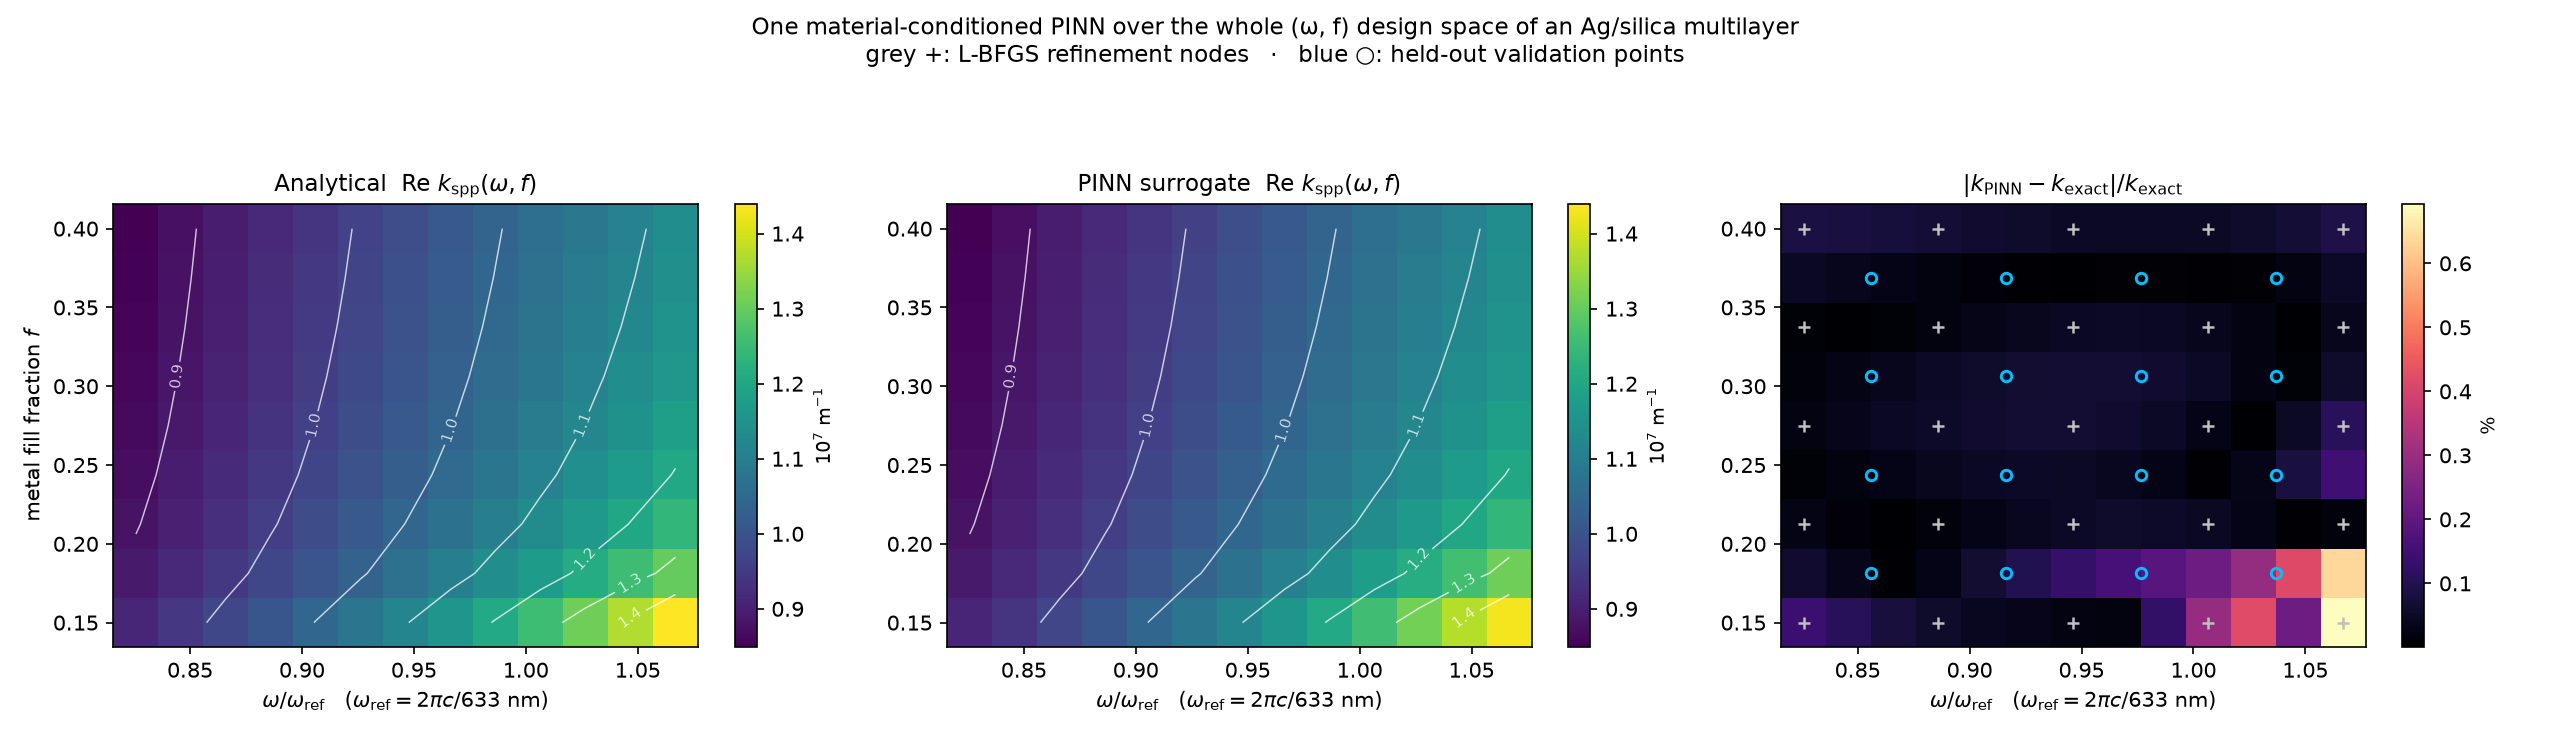

In [15]:
display(Image(filename=str(FIGURES / "hmm_surrogate" / "k_spp_surface.png"), width=980))

## 6. Where this stops being true

### 6.1 Homogenisation is worse than the usual rule suggests

Most of the metamaterial results in this project replace the multilayer by a single uniform
uniaxial medium. The standard guard for that is "period much smaller than the wavelength",
which at 633 nm gives about 33 nm — and the 30 nm stack passes it.

Testing the substitution directly against a transfer-matrix solve of the real stack shows
the guard is roughly an order of magnitude too loose for a *surface* mode. The leading error
is **$O(a)$** in the layer period, not the $O((a/\lambda)^2)$ bulk term the rule addresses,
because the dominant contribution is a **termination** effect: a truncated periodic stack
has a surface, and the surface is not homogenised. The signature is unambiguous —
metal-terminated and dielectric-terminated stacks err by equal magnitudes with opposite
signs, and terminating with a *half*-thickness metal layer places the effective boundary at
that layer's centre, cancels the $O(a)$ term and restores $O(a^2)$.

The sweep below is computed live: for each period, a stack of fixed 800 nm total thickness
is built and solved exactly, and compared with the homogenised prediction.

In [16]:
TOTAL_THICKNESS = 800e-9
periods_nm = np.unique(np.round(np.logspace(np.log10(1.0), np.log10(60.0), 22), 6))
terminations = {"metal": "tab:red", "dielectric": "tab:purple", "half-metal": "tab:green"}

sweep = {}
for term, _ in terminations.items():
    errs_re, errs_im = [], []
    for a_nm in periods_nm:
        a = a_nm * 1e-9
        n_per = max(4, int(round(TOTAL_THICKNESS / a)))
        layers, ths = multilayer_stack(a, n_per, termination=term)
        k = tm.find_mode(k_emt, K0, layers, ths)
        # Normalised by the EMT value, matching examples/emt_validity.py.
        errs_re.append(abs(k_emt.real - k.real) / abs(k_emt.real))
        errs_im.append(abs(k_emt.imag - k.imag) / abs(k_emt.imag))
    sweep[term] = (np.array(errs_re), np.array(errs_im))

# Fit the power law on the small-period end only, where the asymptotics hold.
FIT_MAX_NM = 12.0
fit = periods_nm <= FIT_MAX_NM
print(f"error ~ a^p, fitted over a <= {FIT_MAX_NM:.0f} nm ({fit.sum()} points)")
for term in terminations:
    p_re, p_im = (np.polyfit(np.log(periods_nm[fit]), np.log(e[fit]), 1)[0]
                  for e in sweep[term])
    print(f"  {term:<12} p(Re k_spp) = {p_re:.2f}    p(Im k_spp) = {p_im:.2f}")

error ~ a^p, fitted over a <= 12 nm (13 points)
  metal        p(Re k_spp) = 0.97    p(Im k_spp) = 0.98
  dielectric   p(Re k_spp) = 1.03    p(Im k_spp) = 1.02
  half-metal   p(Re k_spp) = 2.00    p(Im k_spp) = 1.97


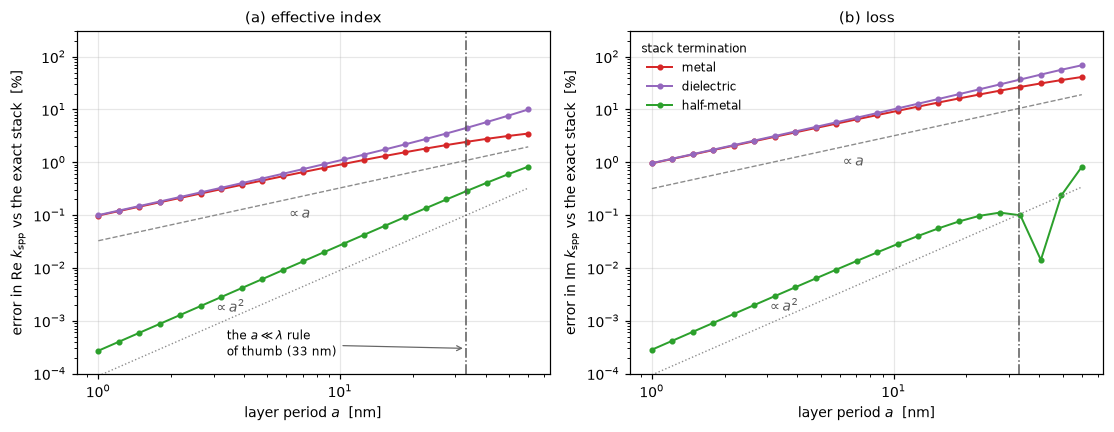

In [17]:
fig, (ax_re, ax_im) = plt.subplots(1, 2, figsize=(10.2, 4.0), sharex=True)
for term, colour in terminations.items():
    e_re, e_im = sweep[term]
    ax_re.loglog(periods_nm, e_re * 100, "o-", color=colour, ms=3, lw=1.3, label=term)
    ax_im.loglog(periods_nm, e_im * 100, "o-", color=colour, ms=3, lw=1.3, label=term)

for ax, key, label in ((ax_re, 0, r"Re $k_\mathrm{spp}$"), (ax_im, 1, r"Im $k_\mathrm{spp}$")):
    # Slope guides anchored a factor of 3 below the curve they refer to.
    g1 = sweep["metal"][key][0] / 3.0 * periods_nm
    g2 = sweep["half-metal"][key][0] / 3.0 * periods_nm**2
    ax.loglog(periods_nm, g1 * 100, "--", color="0.55", lw=0.9)
    ax.loglog(periods_nm, g2 * 100, ":", color="0.55", lw=0.9)
    ax.annotate(r"$\propto a$", xy=(6.0, np.interp(6.0, periods_nm, g1) * 100 * 0.45),
                color="0.35", fontsize=9)
    ax.annotate(r"$\propto a^{2}$", xy=(3.0, np.interp(3.0, periods_nm, g2) * 100 * 1.8),
                color="0.35", fontsize=9)
    ax.axvline(A_MAX * 1e9, color="0.35", lw=1.0, ls="-.")
    ax.set_xlabel("layer period $a$  [nm]")
    ax.set_ylabel(f"error in {label} vs the exact stack  [%]")
    ax.set_ylim(1e-4, 3e2)

ax_re.annotate(f"the $a \\ll \\lambda$ rule\nof thumb ({A_MAX * 1e9:.0f} nm)",
               xy=(A_MAX * 1e9, 3e-4), xytext=(3.4, 2.2e-4), fontsize=8,
               arrowprops=dict(arrowstyle="->", lw=0.8, color="0.4"))
ax_re.set_title("(a) effective index")
ax_im.set_title("(b) loss")
ax_im.legend(title="stack termination", fontsize=8, title_fontsize=8, loc="upper left")
fig.tight_layout()
plt.show()

The fitted exponents say it plainly: metal- and dielectric-terminated stacks scale as
$a^{0.97}$ and $a^{1.03}$ — a surface term — while the half-metal termination scales as
$a^{2.0}$ and stays under 1% out to a 60 nm period. (The notch in the half-metal loss curve
near 40 nm is a sign change, where the residual error passes through zero on its way from
one side to the other — the plot shows magnitudes.) Reading off the metal-terminated curve
at the periods quoted in the project's limitations page:

| layer period | error in Re $k_\mathrm{spp}$ | error in Im $k_\mathrm{spp}$ |
| --- | --- | --- |
| 2 nm | 0.2% | 1.9% |
| 10 nm | 0.9% | 9.1% |
| 30 nm | 2.3% | 24% |

So homogenised **dispersion** is reliable, but homogenised **loss figures** — propagation
lengths, quality factors, anything derived from $\operatorname{Im}k$ — are optimistic unless
the period is genuinely small.

One bookkeeping note, because the same quantity appears with two values in the project's
documents. The sweep above normalises the discrepancy by the *EMT* value, which is what
`emt_validity.py` does, and gives 24% at 30 nm. The multilayer experiment normalises by the
*transfer-matrix* value, because there the transfer matrix is the declared truth, and gives
33.6%. Same discrepancy, different denominator.

### 6.2 The honest caveat on the headline

$\operatorname{Im}k_\mathrm{spp}$ is measured from $-\mathrm{d}\ln|H_y|/\mathrm{d}x$, and
across the $2\lambda_\mathrm{spp}$ box the true mode's amplitude falls by only about 1%. A
single-line fit is therefore a small difference of nearly equal numbers.

In [18]:
print(f"probe lines used                    : {metrics['k_spp_n_probe_lines']:.0f}")
print(f"signal-weighted mean (the reported) : {metrics['k_spp_im_pinn']:.0f} 1/m"
      f"  ({metrics['k_spp_im_rel_error'] * 100:.2f}% high)")
print(f"1 sigma across lines                : {metrics['k_spp_im_std']:.0f} 1/m"
      f"  = {metrics['k_spp_im_std_over_tmm'] * 100:.1f}% of the TMM value")
print(f"full spread (max - min)             : {metrics['k_spp_im_spread_over_tmm'] * 100:.0f}%"
      " of the TMM value")
print(f"worst single line                   : {metrics['k_spp_im_worst_rel_error'] * 100:.1f}%")
print()
print("By contrast the real part is sharp:")
print(f"worst single probe line, Re k_spp   : {metrics['k_spp_re_worst_rel_error'] * 100:.3f}%")

probe lines used                    : 20
signal-weighted mean (the reported) : 8982 1/m  (1.92% high)
1 sigma across lines                : 1341 1/m  = 15.2% of the TMM value
full spread (max - min)             : 52% of the TMM value
worst single line                   : 36.2%

By contrast the real part is sharp:
worst single probe line, Re k_spp   : 0.022%


The aggregate is good and robustly so — unweighted mean 3.0%, median 2.1%, signal-weighted
1.9%, every sensible aggregate between 1.7% and 3.2% — but any individual line is worth
±15%, and the worst one (36%) is marginally worse than the homogenised model. The 17.5×
improvement on $\operatorname{Im}k$ is real, and should be quoted as "an aggregate estimate,
$1\sigma \approx 15\%$", not as a 1.9% measurement. The scatter is a property of the
estimator's dynamic range, not of the mode: run on the exact transfer-matrix field the same
estimator has zero spread.

The asymmetry is structural, not a PINN problem. The phase advances $4\pi$ across the box
while the amplitude changes by 1%. Any fixed-box mode solver has it, and it is why the loss
figure needs an error bar and the index does not. The fix is a wider box, not a better
network.

### 6.3 Scope, and what this does not show

- **One structure, one frequency, one seed.** The 472× and 17.5× ratios come from a single
  run at 633 nm on a single geometry. No $\omega$ conditioning on the layered stack, no
  sweep over the period, no seed ensemble.
- **The anchor is the transfer-matrix profile on all six faces.** The network is not
  *discovering* the mode from physics alone — it is told the mode on the boundary and asked
  to fill in the interior consistently with Maxwell. The comparison is still meaningful,
  because the wavevector fit is done in the interior at heights the anchor does not pin, and
  a network that merely interpolated its boundary data sloppily would not reach 0.005%. But
  "the layered representation is learnable and accurate" is a weaker claim than "the PINN
  found the mode", and only the first is demonstrated.
- **The transfer matrix is faster and exact for planar stacks.** For this problem the
  reference beats the network on every axis except one. The case for the network is
  generalisation to geometries where no such reference exists — which this project has not
  yet demonstrated.
- **Material and geometry idealisations.** Silver is a Drude fit with no interband
  transitions: within 3% of Johnson & Christy at 633 nm, but degrading below about 450 nm,
  and with an imaginary part roughly three times too small, so Drude-based propagation
  lengths are optimistic before homogenisation even enters. The geometry is planar and
  laterally infinite throughout — no roughness, no finite beams, no edges.
- **Numerics.** Training is CPU-bound at roughly 30–80 minutes per experiment. Single
  precision sets a residual floor near $10^{-3}$ relative, so the refinement phase runs in
  double precision. The multilayer run's L-BFGS phase had not converged at its 60-step
  budget — the loss was still falling monotonically when the clock ran out.
- **Known weak spot.** The silver-side curl residual in the multilayer run is 0.19 (curl-E)
  and 0.42 (curl-H) relative, much larger than in air. The solution is accurate despite it,
  which means the metal-side physics is being carried by the anchor more than by its own
  residual. The $|\varepsilon_{Ag}|^{-1/2}$ preconditioner still under-weights it.

## 7. Where to look next

| you want | look at |
| --- | --- |
| the conventions, equations and loss design | `docs/physics.md` |
| what each physics routine is benchmarked against | `docs/validation.md` |
| the experiments in detail | `docs/results.md` |
| the full honest caveats | `docs/limitations.md` |
| per-experiment records: hyperparameters, what failed, what was fixed | `docs/plans/*.md` |
| the numbers behind every figure | `figures/*/metrics.json` |
| the library used above | `src/effective_medium.py`, `src/physics/metamaterial.py`, `src/transfer_matrix.py` |

The analytics-only studies under `examples/` run in seconds and need no training; the
training experiments take 30–80 minutes on CPU and all support `--resume`. `pytest -q` runs
the 865-test suite, and `scripts/validate_physics.py` runs the standalone physics checks.

---

*Dr Robert Michael Jones — Applied AI Scientist, Whitespace; previously Department of
Physics, King's College London.
[ORCID 0000-0002-5422-3088](https://orcid.org/0000-0002-5422-3088). Funding: URF\\R1\\231460.*